# Importing 


In [1]:
import cv2
from pathlib import Path
import pandas as pd 
from text_cleaner import TextCleaner
import matplotlib.pyplot as plt
import random
import numpy as np
from torchvision import models, transforms
import torch
import torch.nn as nn
import nltk
from torch.utils.data import Dataset , DataLoader , TensorDataset
from torchvision.models.feature_extraction import create_feature_extractor
from nltk.tokenize import word_tokenize
from collections import Counter
from bert_score import score as bertscore
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
import pickle
nltk.download('punkt_tab')



#-----------------------------------
random.seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

#----------------------------------
script_path = Path.cwd()
images_folder_path = script_path.joinpath("Images")
# print (images_folder_path)
images_paths = list(images_folder_path.glob("*.jpg"))

captions_df = pd.read_csv("captions.csv")

print(captions_df.shape)
print(captions_df.isna().sum())
# print(captions_df.head(5))



/home/youssef/venv_py312/lib/python3.12/site-packages/nltk/downloader.py:1076: UserWarning: NLTK will not authorize the non-private download directory '/home/youssef/nltk_data': it (or an ancestor) is world- or group-writable, so another local user could plant files there. Choose a private location such as ~/nltk_data.
  for msg in self.incr_download(info_or_id, download_dir, force):


cuda
(40455, 2)
image      0
caption    0
dtype: int64


[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/youssef/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


## Helpers


In [2]:
#since my opencv doesn't have GUI and i don't have time to go through this process i'll use matplotlip for visuals
def matplot_show(image) :
    image = cv2.cvtColor(image , cv2.COLOR_BGR2RGB)
    plt.imshow(image)
    plt.axis("off")
    plt.show()

In [ ]:
#to save on lowest bleu rather than least validation loss ,for some reason it's always stuck after 4th epoch no matter what i try
def val_bleu(model, val_dict_subset, val_features, device):
    names = list(val_dict_subset.keys())
    generated = [beam_search_generate(model, val_features[n], word2idx, idx2word, device=device) for n in names]
    refs = [reference_dict[n] for n in names]
    refs_tok = [[r.split() for r in rs] for rs in refs]
    cands_tok = [g.split() for g in generated]
    smoothie = SmoothingFunction().method4
    return corpus_bleu(refs_tok, cands_tok, weights=(0.25,0.25,0.25,0.25), smoothing_function=smoothie)

## Attention 

In [3]:
class Attention(nn.Module):
    def __init__(self, feature_dim, hidden_dim, attn_dim):
        super().__init__()
        self.feature_proj = nn.Linear(feature_dim, attn_dim)
        self.hidden_proj = nn.Linear(hidden_dim, attn_dim)
        self.coverage_proj = nn.Linear(1, attn_dim)   
        self.score_proj = nn.Linear(attn_dim, 1)

    def forward(self, features, hidden, coverage):
        # running sum of past attention weights
        proj_features = self.feature_proj(features)
        proj_hidden = self.hidden_proj(hidden).unsqueeze(1)
        proj_coverage = self.coverage_proj(coverage.unsqueeze(2))   
        scores = self.score_proj(torch.tanh(proj_features + proj_hidden + proj_coverage)).squeeze(2)
        weights = torch.softmax(scores, dim=1)
        context = (features * weights.unsqueeze(2)).sum(dim=1)
        return context, weights

    

# Phase 1 :Dataset

## Preprocessing


In [4]:
#keeping names to connect them later to the texts
images = {image_path.name : cv2.imread(str(image_path)) for image_path in images_paths}
#removing none image
images = {name : image for name,image in images.items() if image is not None}


#
# clean the caption text
cleaner = TextCleaner(str_series= captions_df["caption"])
cleaned_captions = cleaner.clean_series()
captions_df = captions_df.loc[cleaned_captions.index].assign(caption=cleaned_captions)

captions_dict = captions_df.groupby("image")["caption"].apply(list).to_dict()
print (captions_dict["3488512097_e500cb499f.jpg"])


Text cleaned
['a man dressed in gray gear including helmet races a dirt bike on a dirt track', 'a man in a black uniform and helmet dirtracing with his bike s front wheel in midair', 'a man riding a dirt bike', 'a motorcycle racer is in action at the track', 'biker riding dirt bike on dirt track']


## Connecting each image name with image and captions

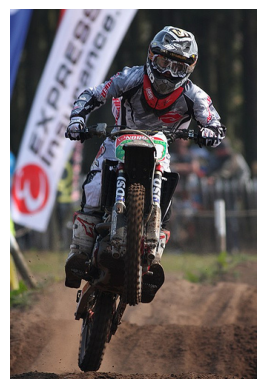

In [5]:

image_text_merged = {}
for img_name, image in images.items():
    image_captions = captions_dict.get(img_name)
    
    if image_captions is None:
        print(f"Warning: no captions found for {img_name}")
        continue

    image_text_merged[img_name] = {
        "image": image,
        "captions": image_captions
    }

image = image_text_merged["3488512097_e500cb499f.jpg"]["image"]
matplot_show(image=image)

## Data Splitting 

In [6]:
items = list(image_text_merged.items())
random.shuffle(items)

total_len = len(items)
train_size = int(total_len * 0.8)
val_size = int(total_len * 0.1)


train_set = items[:train_size]
valid_set = items[train_size : train_size + val_size]
test_set  = items[train_size + val_size : ]

#converting back to dicts
train_dict = dict(train_set)
val_dict = dict(valid_set)
test_dict = dict(test_set)


##checking against leakage 
assert set(train_dict) & set(val_dict) == set()
assert set(train_dict) & set(test_dict)  == set()
assert set(val_dict)   & set(test_dict)  == set()

print(len(train_dict), len(val_dict), len(test_dict))

6472 809 810


# Phase 2 :Image feature Extraction 

## processing images for inceptionV3


In [7]:
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((299,299)),
    transforms.ToTensor(),
    transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
])

#okay i feel like two loops isn't the cleanest approach so i'll try to optimize that later
for dict_ in [test_dict , train_dict , val_dict]:
    for image_name in dict_.keys() :
        # matplot_show(dict_[image_name]["image"])
        # break
        dict_[image_name]["image"] = transform(cv2.cvtColor(dict_[image_name]["image"] , cv2.COLOR_BGR2RGB))


## loading inceptionV3

In [8]:
#i got stuck with the syntax of this part so i used AI
"""
write the syntax for this part
it should have two functions extract_batch and extract_dict, dict is set like {image_name {"image" : tensor ,}}
it should get features from this tensors then return back a feature for each image_name in a dict using zip or any other more suitable method
"""
def extract_dict(data_dict : dict ,batch_size = 32):
    names = list(data_dict.keys())
    features = {}

    for i in range(0, len(names), batch_size):
            batch_names = names[i:i + batch_size]
            batch_tensor = torch.stack([data_dict[n]["image"] for n in batch_names])
            batch_features = extract_batch(batch_tensor)

            for name, feat in zip(batch_names, batch_features):
                features[name] = feat

    return features


In [9]:
weights = models.Inception_V3_Weights.IMAGENET1K_V1
"""
apparently aux_logits activates auxiliary classifiers located in the middle layers which output their own predictions to help along side the final output
that makes spotting / fixing vanishing gradients easier
it acts as a regularizer also since it forces intermediate layers to also learn features well enough to classify

During Inference (Testing/Prediction): The auxiliary networks are discarded. The model only uses the final, main output to make predictions.
"""
model   = models.inception_v3(weights , aux_logits = True)
model.fc = nn.Identity() #removing final classifier since we'll replace it with our usecase
model.eval()
model.to(device)
feature_extractor = create_feature_extractor(model, return_nodes={"Mixed_7c": "features"})


def extract_batch(batch):
    batch = batch.to(device)
    with torch.no_grad():
        features = feature_extractor(batch)["features"]   # (batch, 2048, 8, 8)
        features = features.flatten(2).permute(0, 2, 1)     # (batch, 64, 2048)
    return features.cpu()

#
train_features = extract_dict(train_dict)
val_features   = extract_dict(val_dict)
test_features  = extract_dict(test_dict)



/home/youssef/venv_py312/lib/python3.12/site-packages/torchvision/models/_utils.py:135: UserWarning: Using 'weights' as positional parameter(s) is deprecated since 0.13 and may be removed in the future. Please use keyword parameter(s) instead.
  warnings.warn(
/home/youssef/venv_py312/lib/python3.12/site-packages/torchvision/models/feature_extraction.py:175: UserWarning: NOTE: The nodes obtained by tracing the model in eval mode are a subsequence of those obtained in train mode. When choosing nodes for feature extraction, you may need to specify output nodes for train and eval mode separately.
  warnings.warn(msg + suggestion_msg)


## Caching 

In [10]:
torch.save(train_features, "train_features.pt")
torch.save(val_features, "val_features.pt")
torch.save(test_features, "test_features.pt")

# Phase3 : Text Processing 

## Tokenization 

In [11]:
for data_dict in [train_dict , test_dict , val_dict] :
    for image_name in data_dict.keys():
        for i ,  caption in enumerate(data_dict[image_name]["captions"]):
            data_dict[image_name]["captions"][i] = word_tokenize(data_dict[image_name]["captions"][i])
            # print(data_dict[image_name]["captions"][i])
            # break

# ._. yes i should stop this for loops , i realize those will be better above before even creating the big dictionaries and having to loop
# but i'll continue with the phases to understand things clearly then i'll try polishing

## Building Vocab

In [12]:
word_counts = {}


for file_name in train_dict.keys():
    for caption in train_dict[file_name]["captions"]:
        for token in caption:
            word_counts[token] = word_counts.get(token, 0) + 1

print("n of unique words")
print(len(word_counts.items()))

freq_values = list(word_counts.values())
for n in [1, 2, 3, 5 , 6 , 7, 8 ,16 , 24 ,32]:
    below = sum(1 for c in freq_values if c <= n)
    print(f"words with freq <= {n}: {below} / {len(word_counts)} ({below/len(word_counts):.1%})")

n of unique words
7944
words with freq <= 1: 3249 / 7944 (40.9%)
words with freq <= 2: 4274 / 7944 (53.8%)
words with freq <= 3: 4884 / 7944 (61.5%)
words with freq <= 5: 5573 / 7944 (70.2%)
words with freq <= 6: 5775 / 7944 (72.7%)
words with freq <= 7: 5940 / 7944 (74.8%)
words with freq <= 8: 6079 / 7944 (76.5%)
words with freq <= 16: 6698 / 7944 (84.3%)
words with freq <= 24: 6975 / 7944 (87.8%)
words with freq <= 32: 7131 / 7944 (89.8%)


## Handling Special tokens

In [13]:
def encode(tokens, word2idx):
    ids = [word2idx["<start>"]]
    ids += [word2idx.get(tok, word2idx["<unk>"]) for tok in tokens]
    ids += [word2idx["<end>"]]
    return ids

def decode(ids, idx2word):
    return [idx2word.get(i, "<unk>") for i in ids]

In [14]:
word2idx = {"<pad>": 0, "<start>": 1, "<end>": 2, "<unk>": 3}
index = 4
for word, count in word_counts.items():
    if count >= 2:
        word2idx[word] = index
        index += 1

idx2word = {i: w for w, i in word2idx.items()}

In [15]:
for data_dict in [train_dict, val_dict, test_dict]:
    for image_name in data_dict.keys():
        for i, caption in enumerate(data_dict[image_name]["captions"]):
            data_dict[image_name]["captions"][i] = encode(caption, word2idx)

## Padding

In [16]:
def pad_sequence(ids, max_len, pad_id=0, end_id=2):
    if len(ids) > max_len:
        ids = ids[:max_len - 1] + [end_id]
        return ids
    return ids + [pad_id] * (max_len - len(ids))

In [17]:
#checking lengths first
lengths = [
    len(caption)
    for image_name in train_dict.keys()
    for caption in train_dict[image_name]["captions"]
]

print(f"max: {max(lengths)}, mean: {np.mean(lengths):.1f}, 95th pct: {np.percentile(lengths, 95):.0f}")

max_len = 20
for data_dict in [train_dict, val_dict, test_dict]:
    for image_name in data_dict.keys():
        for i, caption in enumerate(data_dict[image_name]["captions"]):
            data_dict[image_name]["captions"][i] = pad_sequence(caption, max_len, word2idx["<pad>"])


#caching for later
with open("word2idx.pkl", "wb") as f:
       pickle.dump(word2idx, f)
with open("idx2word.pkl", "wb") as f:
       pickle.dump(idx2word, f)

max: 37, mean: 12.8, 95th pct: 20


# Phase4 : Caption Generation Model

In [18]:
from typing import Any


class CaptionDecoder(nn.Module):
    def __init__(self, vocab_size , embed_dim = 256 , hidden_dim = 512 , image_feature_dim = 2048
                 , num_layers = 1 , dropout = 0.5):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size , embedding_dim= embed_dim , padding_idx= 0) #the padding idx is 0 similar to the one we set it 
        self.image_projection = nn.Linear(image_feature_dim , embed_dim)

        self.lstm = nn.LSTM(input_size= embed_dim * 2 , hidden_size= hidden_dim , num_layers= num_layers , batch_first= True 
                            , dropout= dropout if num_layers > 1 else 0)

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim , vocab_size) #the last layer we removed earlier to set our own

    def forward(self, image_features , captions_ids):
        word_embeds = self.embedding(captions_ids)       
        # print (word_embeds.shape)             

        img_embed = self.image_projection(image_features).unsqueeze(1)    
        img_embed = img_embed.expand(-1, word_embeds.size(1), -1)    

        merged = torch.cat([word_embeds, img_embed], dim=2)         
        merged = self.dropout(merged)
        # print(merged.shape)

        lstm_out, _ = self.lstm(merged)                              
        logits = self.fc(lstm_out)                                   

        return logits
        

In [19]:
class AttentionCaptionDecoder(nn.Module):
    def __init__(self, vocab_size, embed_dim=256, hidden_dim=512, feature_dim=2048, attn_dim=256, dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.attention = Attention(feature_dim, hidden_dim, attn_dim)
        self.lstm_cell = nn.LSTMCell(embed_dim + feature_dim, hidden_dim)
        self.init_h = nn.Linear(feature_dim, hidden_dim)
        self.init_c = nn.Linear(feature_dim, hidden_dim)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def init_hidden_state(self, features):
        mean_features = features.mean(dim=1)     # (batch, feature_dim) — average over regions
        return self.init_h(mean_features), self.init_c(mean_features)

    def forward(self, features, captions_ids):
        # features:      (batch, num_regions, feature_dim)
        # captions_ids:  (batch, seq_len)
        batch_size, seq_len = captions_ids.shape
        num_regions = features.size(1)
        word_embeds = self.embedding(captions_ids)

        h, c = self.init_hidden_state(features)
        coverage = torch.zeros(batch_size, num_regions, device=features.device)  

        outputs = torch.zeros(batch_size, seq_len, self.fc.out_features, device=features.device)
        all_weights = torch.zeros(batch_size, seq_len, num_regions, device=features.device)

        for t in range(seq_len):
            context, weights = self.attention(features, h, coverage)   # pass coverage in
            coverage = coverage + weights                               
            lstm_input = torch.cat([word_embeds[:, t, :], context], dim=1)
            h, c = self.lstm_cell(lstm_input, (h, c))
            outputs[:, t, :] = self.fc(self.dropout(h))
            all_weights[:, t, :] = weights

        return outputs, all_weights

# Phase 5 :Training 

In [ ]:
class CaptionDataset(Dataset):
    def __init__(self, data_dict, features_dict):
        self.samples = []
        for image_name, entry in data_dict.items():
            for caption in entry["captions"]:
                self.samples.append((image_name, caption))
        self.features_dict = features_dict  # shared, not duplicated

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        image_name, caption = self.samples[idx]
        image_feature = self.features_dict[image_name]          # (64, 2048), looked up not copied
        caption_tensor = torch.tensor(caption, dtype=torch.long)
        return image_feature, caption_tensor

train_dataset = CaptionDataset(train_dict, train_features)
val_dataset = CaptionDataset(val_dict, val_features)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

## Design

In [21]:
model = AttentionCaptionDecoder(vocab_size=len(word2idx)).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=word2idx["<pad>"])
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=2
)

## Epoch training 

In [22]:
def train_epoch(model , loader , optimizer , criterion , device = 'cuda' , lambda_reg=1.0):
    model.train()
    total_loss = 0 

    for image_features , captions in loader :
        image_features = image_features.to(device)
        captions = captions.to(device)

        inputs = captions[:, :-1]       #remove last token of input <end>
        targets = captions[:, 1:]       #remove first token of target <start>
        #you end up having 
        # input = <start>  i      love    cats
        # targets = i     love    cats    <end> 

        optimizer.zero_grad()       #since pytorch accumulates gradients by default from previous training steps
        logits, attn_weights = model(image_features, inputs) 

        ce_loss = criterion(logits.reshape(-1, logits.size(-1)), targets.reshape(-1))
        att_reg = ((1. - attn_weights.sum(dim=1)) ** 2).mean()
        loss = ce_loss + lambda_reg * att_reg

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0) #to prevent gradient exploding
        #think 5 is large but i'll assume that it'll be obvious spike on the graph if it happens and will decrease it if tho
        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(loader)

## Epoch Validation

In [23]:
@torch.no_grad()
def validate_epoch(model, loader, criterion, device, lambda_reg=1.0):
    model.eval()
    total_loss = 0
    for image_features, captions in loader:
        image_features = image_features.to(device)
        captions = captions.to(device)
        inputs = captions[:, :-1]
        targets = captions[:, 1:]

        logits, attn_weights = model(image_features, inputs)   # unpack
        ce_loss = criterion(logits.reshape(-1, logits.size(-1)), targets.reshape(-1))
        att_reg = ((1. - attn_weights.sum(dim=1)) ** 2).mean()
        total_loss += (ce_loss + lambda_reg * att_reg).item()

    return total_loss / len(loader)

## Training loop

In [24]:
n_epochs = 30
patience = 3
best_val_loss = float("inf")

epochs_without_improvement = 0 
train_losses , val_losses = [] , [] 


for epoch in range(n_epochs) :
    train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss = validate_epoch(model, val_loader, criterion, device)

    train_losses.append(train_loss) 
    val_losses.append(val_loss)
    scheduler.step(val_loss) #the scheduler we said dependent on val loss

    print(f"epoch {epoch+1}/{n_epochs} - train_loss: {train_loss:.4f} - val_loss: {val_loss:.4f}")

    #that actually gave insight of how yolo will be working 
    if val_loss < best_val_loss :
        best_val_loss = val_loss
        epochs_without_improvement = 0 
        torch.save(model.state_dict(), "best_model.pt")
        print(f"new model saved with {val_loss}")

    else :
        epochs_without_improvement += 1
        if epochs_without_improvement >= patience :
            print(f"early stopping triggered after {epoch+1} epochs")
            break 

epoch 1/30 - train_loss: 4.3825 - val_loss: 3.7490
new model saved with 3.748969590570044
epoch 2/30 - train_loss: 3.7066 - val_loss: 3.5188
new model saved with 3.518759325733335
epoch 3/30 - train_loss: 3.4511 - val_loss: 3.4105
new model saved with 3.41052274628887
epoch 4/30 - train_loss: 3.2729 - val_loss: 3.3602
new model saved with 3.3602291767991432
epoch 5/30 - train_loss: 3.1342 - val_loss: 3.3303
new model saved with 3.3303105493230145
epoch 6/30 - train_loss: 3.0124 - val_loss: 3.3288
new model saved with 3.3288016319274902
epoch 7/30 - train_loss: 2.9122 - val_loss: 3.3404
epoch 8/30 - train_loss: 2.8214 - val_loss: 3.3456
epoch 9/30 - train_loss: 2.7432 - val_loss: 3.3754
epoch 10/30 - train_loss: 2.5731 - val_loss: 3.3598
epoch 11/30 - train_loss: 2.5007 - val_loss: 3.3747
early stopping triggered after 11 epochs


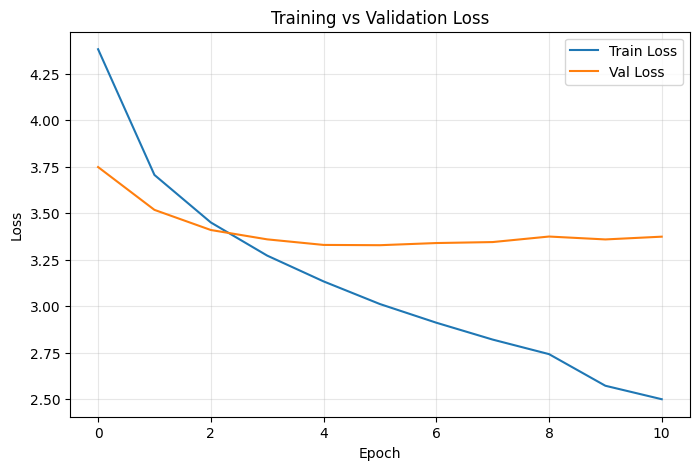

In [25]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Phase 6 : Evaluation 

## Beam search decoding


In [33]:
#penalizing repeated words , since i got a mean with a man .. in one of the inspected images
def has_repeat_ngram(seq, n=2):
    ngrams = [tuple(seq[i:i+n]) for i in range(len(seq) - n + 1)]
    return len(ngrams) != len(set(ngrams))

@torch.no_grad()
def beam_search_generate(model, image_feature, word2idx, idx2word, beam_width=4, max_len=20, alpha=0.7, device="cpu"):
    model.load_state_dict(torch.load("best_model.pt", map_location=device))
    model.eval()
    start_id = word2idx["<start>"]
    end_id = word2idx["<end>"]
    pad_id = word2idx["<pad>"]

    image_feature = image_feature.unsqueeze(0).to(device)  # (1, 2048)

    active_beams = [([start_id], 0.0)]
    completed_beams = []

    for _ in range(max_len):
        candidates = []
        for seq, score in active_beams:
            input_ids = torch.tensor([seq], dtype=torch.long, device=device)
            logits, _ = model(image_feature, input_ids)
            log_probs = torch.log_softmax(logits[0, -1], dim=-1)

            top_log_probs, top_ids = log_probs.topk(beam_width)
            for log_p, token_id in zip(top_log_probs.tolist(), top_ids.tolist()):
                candidates.append((seq + [token_id], score + log_p))

        candidates.sort(key=lambda x: x[1], reverse=True)
        candidates = candidates[:beam_width]
        candidates = [c for c in candidates if not has_repeat_ngram(c[0], n=3)] or candidates

        active_beams = []
        for seq, score in candidates:
            if seq[-1] == end_id:
                completed_beams.append((seq, score))
            else:
                active_beams.append((seq, score))

        if not active_beams:
            break

    completed_beams.extend(active_beams)  # capture any beams still running at max_len

    def normalized_score(seq, score):
        return score / (len(seq) ** alpha)   # length normalization, explained below

    best_seq, _ = max(completed_beams, key=lambda x: normalized_score(x[0], x[1]))
    words = [idx2word[i] for i in best_seq if i not in (start_id, end_id, pad_id)]
    return " ".join(words)

In [34]:
image_names = list(test_dict.keys())
generated_captions = []

for image_name in image_names:
    feat = test_features[image_name]
    caption = beam_search_generate(model, feat, word2idx, idx2word, beam_width=3, device=device)
    generated_captions.append(caption)

In [35]:
reference_dict = captions_df.groupby("image")["caption"].apply(list).to_dict()
references = [reference_dict[name] for name in image_names]

In [36]:
from bert_score import score as bertscore
P, R, F1 = bertscore(generated_captions, references, lang="en", verbose=False)
print(f"BERTScore — Precision: {P.mean():.4f}, Recall: {R.mean():.4f}, F1: {F1.mean():.4f}")

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERTScore — Precision: 0.9335, Recall: 0.9288, F1: 0.9280


In [39]:
references_tokenized = [[ref.split() for ref in refs] for refs in references]
candidates_tokenized = [cap.split() for cap in generated_captions]

smoothie = SmoothingFunction().method4

bleu1 = corpus_bleu(references_tokenized, candidates_tokenized, weights=(1, 0, 0, 0), smoothing_function=smoothie)
bleu2 = corpus_bleu(references_tokenized, candidates_tokenized, weights=(0.5, 0.5, 0, 0), smoothing_function=smoothie)
bleu3 = corpus_bleu(references_tokenized, candidates_tokenized, weights=(0.33, 0.33, 0.33, 0), smoothing_function=smoothie)
bleu4 = corpus_bleu(references_tokenized, candidates_tokenized, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smoothie)

print(f"BLEU-1: {bleu1:.4f}")
print(f"BLEU-2: {bleu2:.4f}")
print(f"BLEU-3: {bleu3:.4f}")
print(f"BLEU-4: {bleu4:.4f}")

BLEU-1: 0.6056
BLEU-2: 0.4290
BLEU-3: 0.2997
BLEU-4: 0.1993


2344412916_9a5a9b1c82.jpg -> a man and a woman are walking on a sidewalk


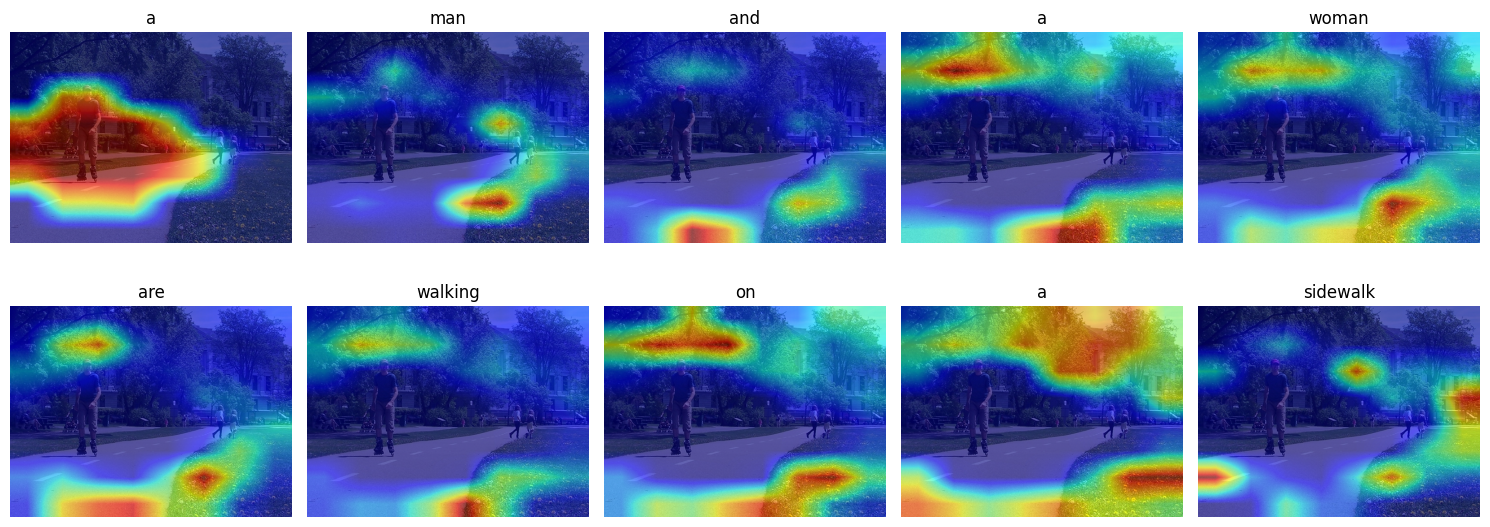

96973080_783e375945.jpg -> a dog runs through the snow


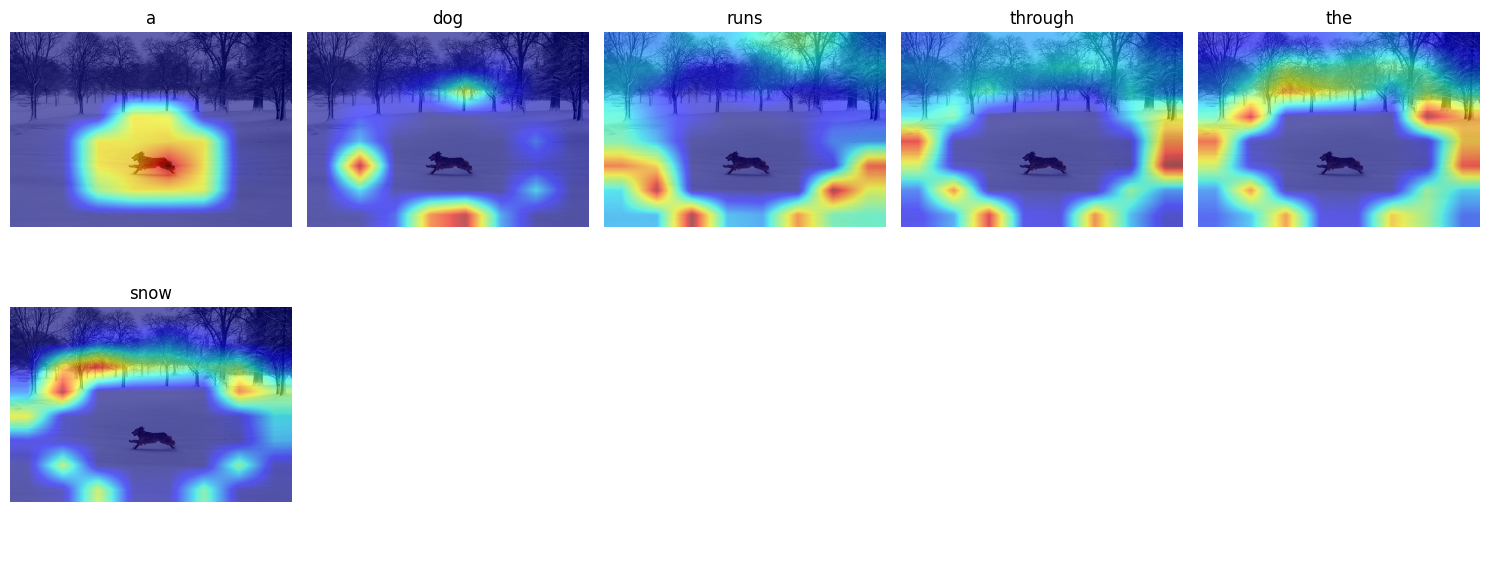

3506607642_40037b3fbf.jpg -> a soccer player in a red uniform is kicking a soccer ball


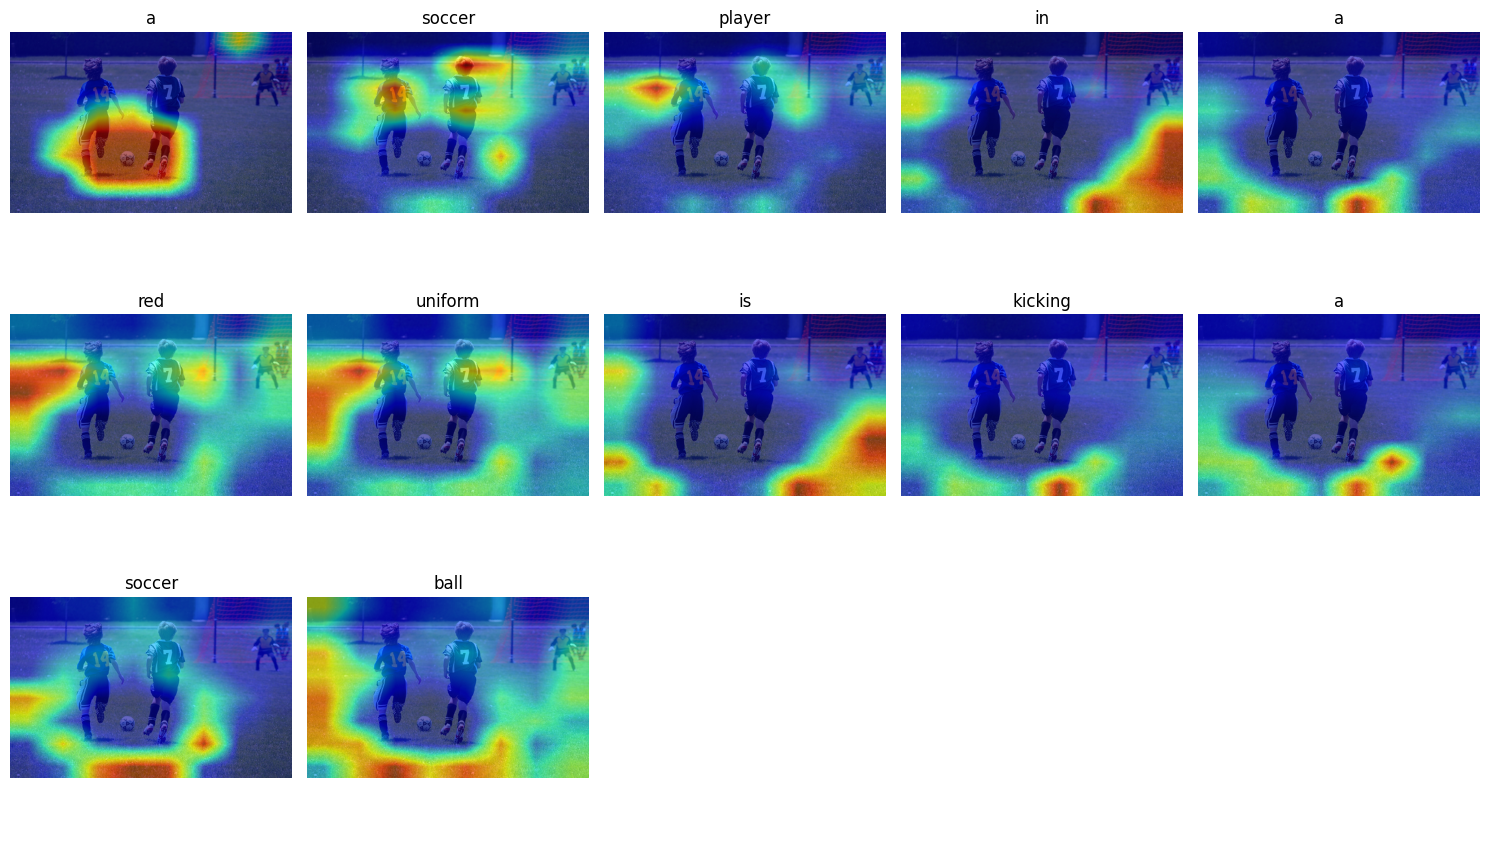

3328535573_33c3cd5b59.jpg -> a group of people are sitting on the beach


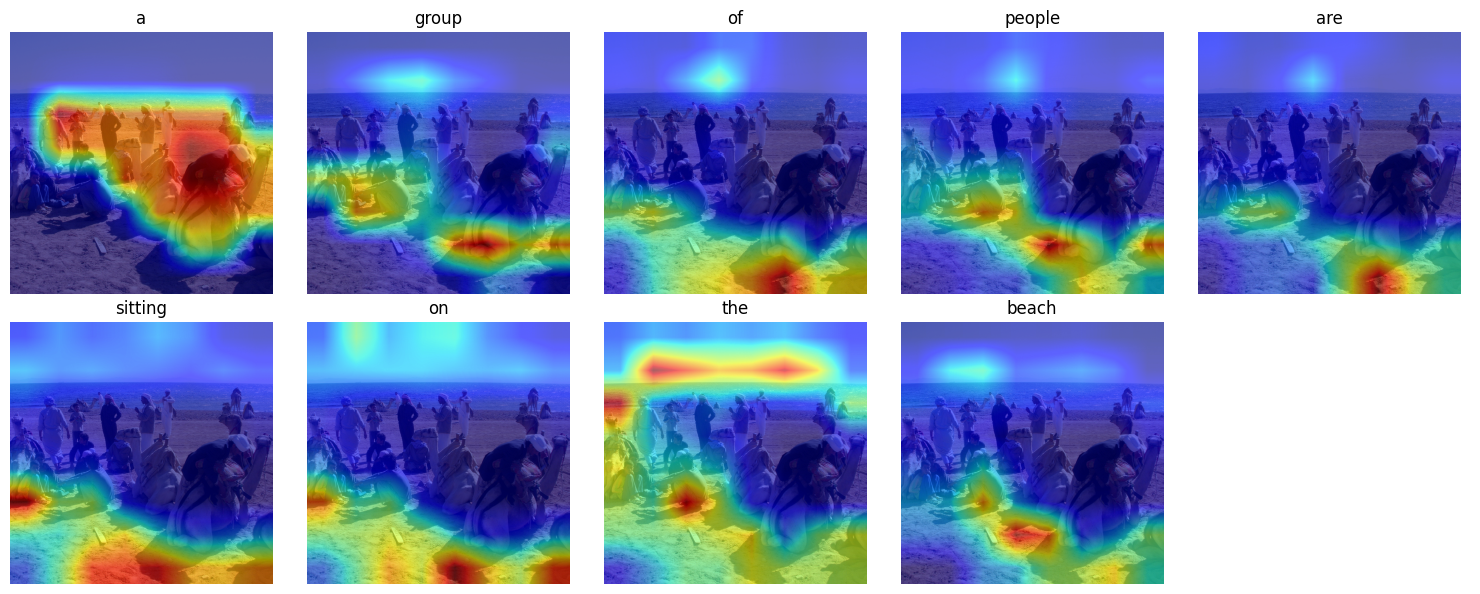

2847859796_4d9cb0d31f.jpg -> a girl in a bathing suit is swimming in a pool


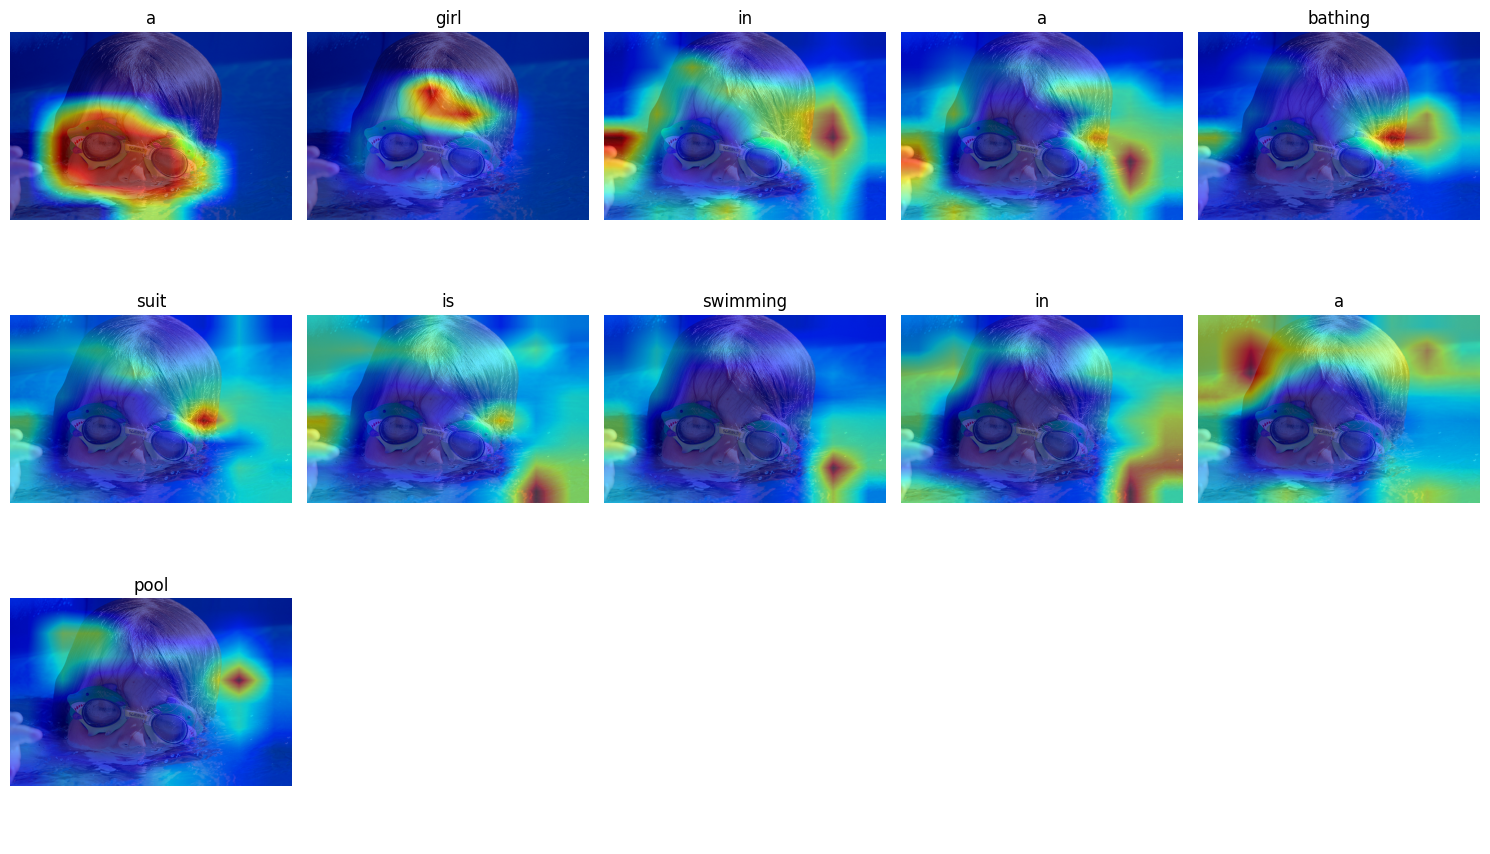

3583516290_1c87a13770.jpg -> a group of people are in a parade


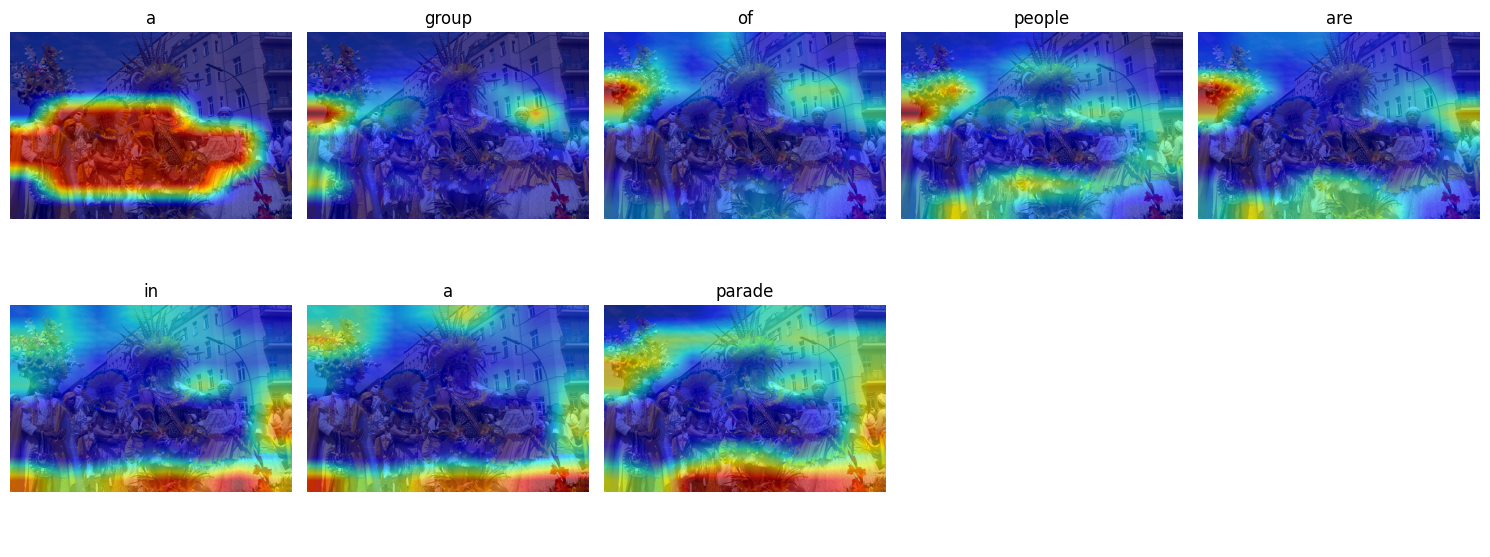

263231469_e85c74f5fd.jpg -> a girl in a bikini is standing on the beach


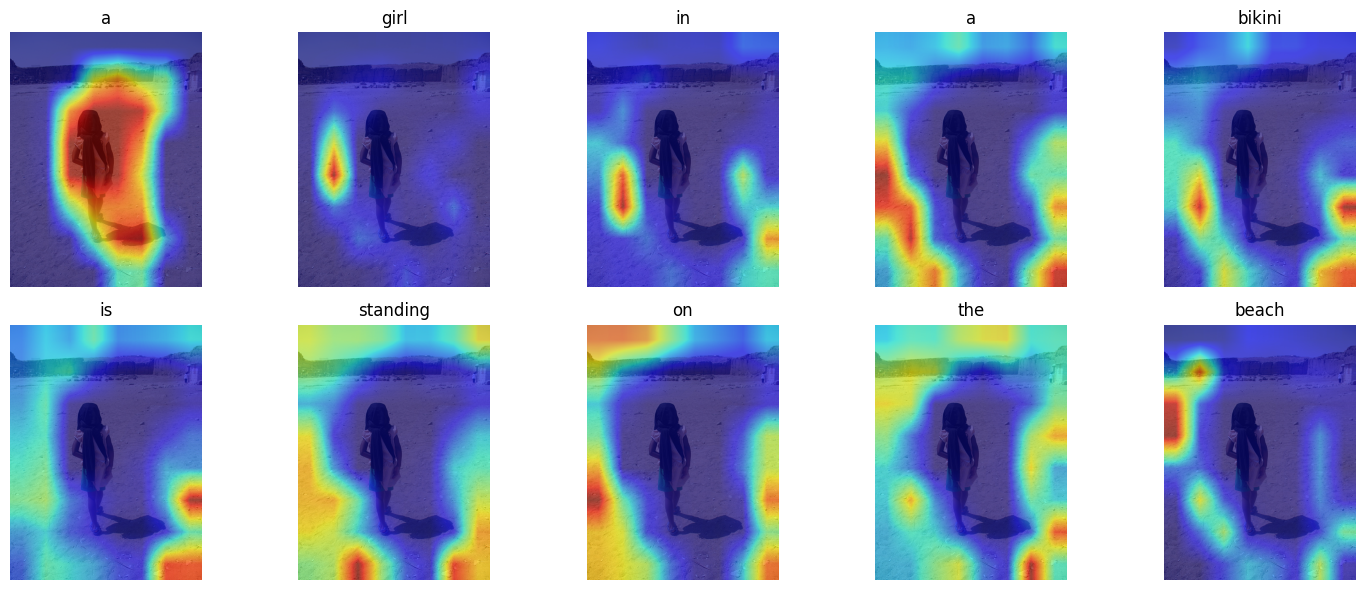

In [41]:
@torch.no_grad()
def generate_with_attention(model, image_feature, word2idx, idx2word, max_len=20, device="cpu"):
    model.eval()
    start_id, end_id = word2idx["<start>"], word2idx["<end>"]

    features = image_feature.unsqueeze(0).to(device)
    h, c = model.init_hidden_state(features)
    coverage = torch.zeros(1, features.size(1), device=device)  

    word_id = start_id
    words, attn_maps = [], []

    for _ in range(max_len):
        word_embed = model.embedding(torch.tensor([word_id], device=device))
        context, weights = model.attention(features, h, coverage)   #pass coverage in
        coverage = coverage + weights                                #update after each step
        lstm_input = torch.cat([word_embed, context], dim=1)
        h, c = model.lstm_cell(lstm_input, (h, c))
        word_id = model.fc(h).argmax(dim=-1).item()

        if word_id == end_id:
            break
        words.append(idx2word[word_id])
        attn_maps.append(weights.squeeze(0).cpu().numpy())

    return words, attn_maps


def show_attention(image_bgr, words, attn_maps, grid_size=8):
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    cols = 5
    rows = (len(words) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
    axes = axes.flatten()

    for i, (word, attn) in enumerate(zip(words, attn_maps)):
        heatmap = cv2.resize(attn.reshape(grid_size, grid_size),
                              (image_rgb.shape[1], image_rgb.shape[0]))
        axes[i].imshow(image_rgb)
        axes[i].imshow(heatmap, alpha=0.6, cmap="jet")
        axes[i].set_title(word)
        axes[i].axis("off")

    for j in range(len(words), len(axes)):
        axes[j].axis("off")
    plt.tight_layout()
    plt.show()


# usage
for image_name in list(test_dict.keys())[:7]:
    raw_image = cv2.imread(str(images_folder_path / image_name))  # reload since tensor overwrote the dict copy
    feat = test_features[image_name]
    words, attn_maps = generate_with_attention(model, feat, word2idx, idx2word, device=device)
    print(image_name, "->", " ".join(words))
    show_attention(raw_image, words, attn_maps)